In [1]:
from Utils.dataset_utils import DatasetUtils
import pandas as pd
from collections import Counter

In [2]:
train_dataset, _ = DatasetUtils.download_celeba(
    train_csv="original_merged",
    base_path="../../../data/celeba",
    debug=True,
)

In [3]:
train_dataset.indexes

range(0, 202599)

In [4]:
df = pd.read_csv("../../../data/celeba/original_merged.csv")

In [5]:
targets = [1 if item == 1 else 0 for item in df["Smiling"]]

sensitive_values = [1 if item == 1 else 0 for item in df["Male"]]

In [6]:
df.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young,split,Target
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,1,-1,1,-1,1,-1,-1,1,0.137514,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,-1,-1,-1,-1,-1,-1,1,-0.432273,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,1,-1,-1,-1,-1,-1,1,1.841473,0
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,1,-1,1,-1,1,1,-1,1,-0.080797,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,1,-1,-1,1,1.045482,1


In [7]:
df.keys()

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young', 'split', 'Target'],
      dtype='object')

In [8]:
df["Attractive"].value_counts()

 1    103833
-1     98766
Name: Attractive, dtype: int64

In [9]:
df_attractive = df[df["Attractive"] == 1]
df_not_attractive = df[df["Attractive"] == -1]

In [10]:
df_attractive.shape

(103833, 43)

In [11]:
df_not_attractive.shape

(98766, 43)

In [12]:
targets = [1 if item == 1 else 0 for item in df_attractive["Smiling"]]

sensitive_values = [1 if item == 1 else 0 for item in df_attractive["Male"]]

sensitive_target = [(s, t) for t, s in zip(targets, sensitive_values)]
Counter(sensitive_target)

Counter({(0, 1): 46168, (0, 0): 34086, (1, 0): 12210, (1, 1): 11369})

In [13]:
# drop 50% of the samples where the target is 1 and the sensitive value is 1
dropped_indexes_1 = (
    df_attractive[(df_attractive["Smiling"] == 1) & (df_attractive["Male"] == -1)].sample(frac=0.5).index
)

dropped_indexes_2 = (
    df_attractive[(df_attractive["Smiling"] == -1) & (df_attractive["Male"] == -1)].sample(frac=0.5).index
)

df_dropped_1 = df_attractive.loc[dropped_indexes_1]
df_dropped_2 = df_attractive.loc[dropped_indexes_2]

df_attractive = df_attractive.drop(dropped_indexes_1)
df_attractive = df_attractive.drop(dropped_indexes_2)


df_attractive.shape

(63706, 43)

In [14]:
df_not_attractive = pd.concat([df_not_attractive, df_dropped_1])
df_not_attractive.shape

(121850, 43)

In [15]:
targets = [1 if item == 1 else 0 for item in df_not_attractive["Smiling"]]

sensitive_values = [1 if item == 1 else 0 for item in df_not_attractive["Male"]]

sensitive_target = [(s, t) for t, s in zip(targets, sensitive_values)]
Counter(sensitive_target)

Counter({(0, 1): 40787, (1, 0): 38426, (1, 1): 22429, (0, 0): 20208})

In [16]:
df_attractive.to_csv("../../../data/celeba/df_attractive.csv")
df_not_attractive.to_csv("../../../data/celeba/df_not_attractive.csv")

# Test New Distribution

In [17]:
train_dataset_attractive, _ = DatasetUtils.download_celeba(
    train_csv="df_attractive",
    base_path="../../../data/celeba",
    debug=True,
)

In [18]:
len(train_dataset_attractive.targets)

63706

In [19]:
from Utils.utils import Utils
from Utils.train_parameters import TrainParameters

/home/lcorbucci/Unfairness-Regularization/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-10-16 11:29:02,054	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
/home/lcorbucci/Unfairness-Regularization/.venv/lib/python3.10/site-packages/wandb/analytics/sentry.py:82: SentryHubDeprecationWarning: `sentry_sdk.Hub` is deprecated and will be removed in a future major release. Please consult our 1.x to 2.x migration guide for details on how to migrate `Hub` usage to the new API: https://docs.sentry.io/platforms/python/migration/1.x-to-2.x
  self.hub = sentry_sdk.Hub(client)


In [20]:
train_parameters = TrainParameters(
    epochs=10,
    device="cuda",
    batch_size=64,
    seed=1,
    metric="disparity",
    optimizer="adam",
)

In [21]:
train_path_attractive = Utils.prepare_dataset_for_FL(
    dataset=train_dataset_attractive,
    dataset_name="celeba",
    base_path="../../../data/",
)

Generating unified dataset
Data Correctly downloaded


Partitioning the dataset
Counter({1: 34453, 0: 29253})
SPLITTING THE DATASET USING the representative partitioning
Mean of disparity 0.09364771596839086 - std 0.05256468061160176
Mean of disparity 0.09364771596839089 - std 0.05256468061160176
[139, 131, 147, 144, 147, 135, 147, 146, 158, 158, 134, 154, 143, 168, 159, 167, 142, 154, 155, 172, 157, 148, 154, 146, 169, 140, 131, 141, 167, 146, 149, 166, 160, 152, 146, 141, 150, 157, 145, 144, 153, 162, 159, 140, 161, 141, 154, 140, 139, 157, 164, 139, 144, 157, 140, 151, 146, 143, 159, 149, 141, 141, 168, 148, 160, 146, 138, 171, 142, 146, 153, 155, 161, 144, 141, 149, 168, 162, 147, 155, 158, 146, 136, 143, 154, 141, 154, 161, 139, 144, 142, 154, 155, 151, 164, 158, 159, 156, 174, 132, 158, 153, 152, 161, 162, 152, 158, 136, 152, 159, 162, 150, 153, 157, 149, 159, 131, 153, 162, 176, 159, 157, 171, 169, 154, 144, 133, 164, 151, 159, 164, 151, 155, 159, 151, 153, 147, 152, 154, 152, 146, 158, 155, 140, 154, 175, 154, 152, 153, 168]
[109, 

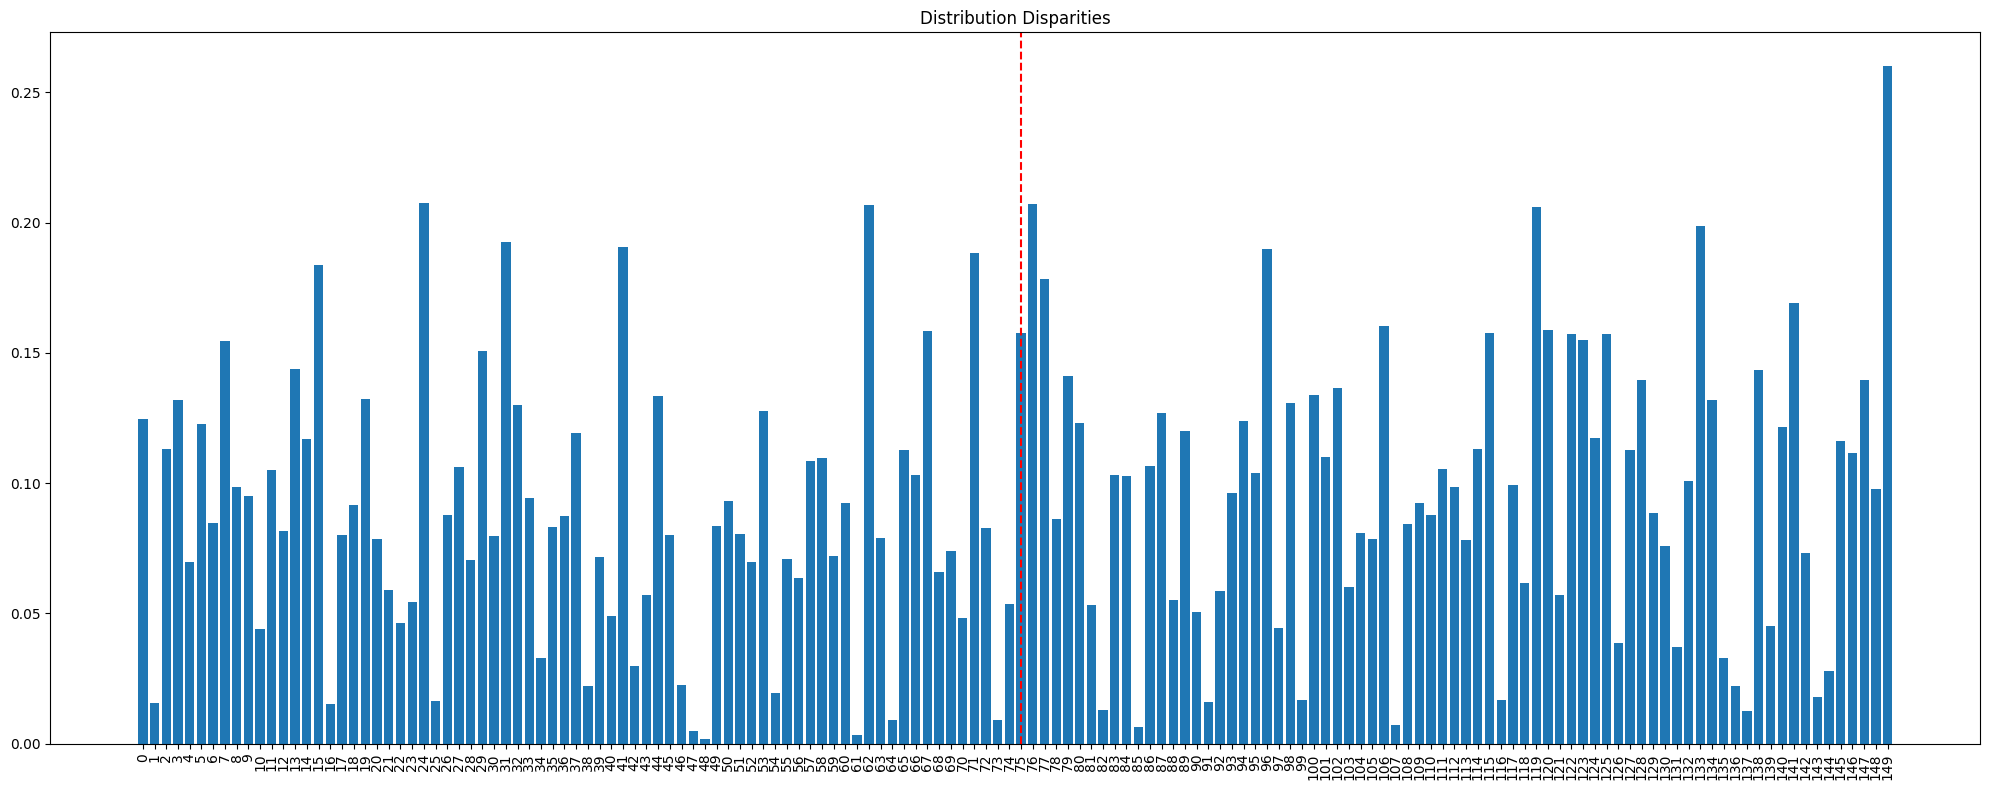

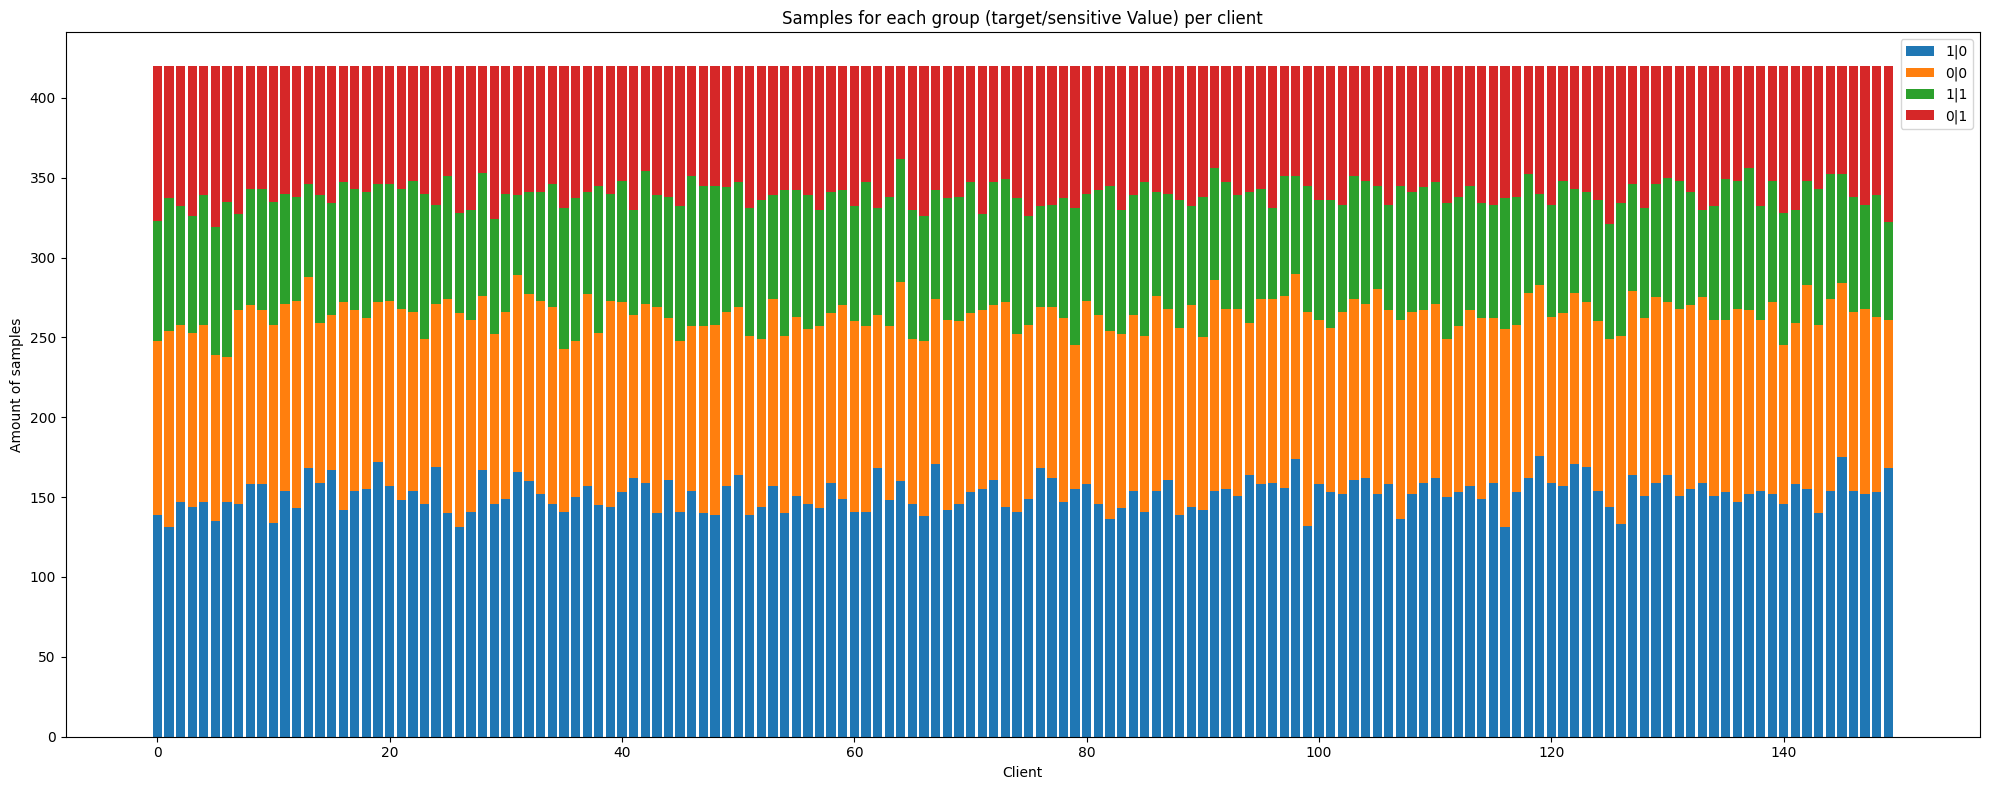

In [22]:
# Attractive Partitioning

# 103833/150
fed_dir = Utils.do_fl_partitioning(
    train_path_attractive,
    pool_size=150,
    num_classes=2,
    val_ratio=0,
    partition_type="representative",
    train_parameters=train_parameters,
    group_to_reduce=(1, 1),
    group_to_increment=(0, 1),
    number_of_samples_per_node=420,
    ratio_unfair_nodes=0.5,
    ratio_unfairness=(0, 0),
    splitted_data_dir="federated",
)

In [23]:
train_dataset_NOT_attractive, _ = DatasetUtils.download_celeba(
    train_csv="df_not_attractive",
    base_path="../../../data/celeba",
    debug=True,
)

len(train_dataset_NOT_attractive.targets)

121850

In [24]:
train_path_NOT_attractive = Utils.prepare_dataset_for_FL(
    dataset=train_dataset_NOT_attractive,
    dataset_name="celeba",
    base_path="../../../data/",
)

Generating unified dataset
Data Correctly downloaded


In [30]:
# Attractive Partitioning
fed_dir = Utils.do_fl_partitioning(
    train_path_NOT_attractive,
    pool_size=150,
    num_classes=2,
    val_ratio=0,
    partition_type="representative",
    train_parameters=train_parameters,
    group_to_reduce=(1, 1),
    group_to_increment=(0, 1),
    number_of_samples_per_node=812,
    ratio_unfair_nodes=0.5,
    ratio_unfairness=(0, 0),
    splitted_data_dir="federated",
)

Partitioning the dataset
Counter({1: 34453, 0: 29253})
SPLITTING THE DATASET USING the representative partitioning


KeyError: (0, 1)